In [1]:
! pip install scipy
! pip install statsmodels

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols

from statsmodels.stats.multicomp import pairwise_tukeyhsd

from statsmodels.stats.anova import anova_lm

In [3]:
data=pd.read_csv('/content/bending modulus data.csv')
data.head()

,system,power,Bending Modulus
0,nile red doped,100,1.860000e-19
1,nile red doped,100,1.580000e-19
2,nile red doped,100,1.340000e-19
3,nile red doped,100,1.540000e-19
4,nile red doped,100,2.210000e-19


In [4]:
! pip install scikit-posthocs

In [5]:

print("\nNumber of observations")
print(data.groupby("system").size())


Number of observations
system
Rhodamine doped    148
nile red doped     130
undoped            131
dtype: int64


In [6]:
summary = (
    data.groupby("system")["Bending Modulus"]
      .agg(["count", "mean", "std", "median", "min", "max"])
)

print(summary)

                 count          mean           std        median  \
system                                                             
Rhodamine doped    148  8.153345e-19  6.472874e-19  6.550000e-19   
nile red doped     130  1.349296e-18  1.200602e-18  9.685000e-19   
undoped            131  9.558969e-19  7.231677e-19  7.980000e-19   

                          min           max  
system                                       
Rhodamine doped  6.640000e-20  4.450000e-18  
nile red doped   7.250000e-20  5.550000e-18  
undoped          0.000000e+00  3.370000e-18  


In [7]:
! pip install seaborn

In [9]:
data["kc_scaled"] = data["Bending Modulus"] / 1e-19

In [10]:
groups = [
    group["kc_scaled"].values
    for _, group in data.groupby("system")
]

In [11]:
print(groups)

[array([ 2.38 ,  1.23 ,  1.34 ,  1.48 ,  2.28 ,  0.726,  1.12 ,  1.02 ,
        0.664,  2.45 ,  0.725,  2.91 ,  1.8  ,  1.57 ,  2.31 ,  2.69 ,
        3.39 ,  2.74 ,  2.88 ,  7.13 ,  3.09 ,  1.63 ,  1.86 ,  1.18 ,
        4.74 ,  1.72 ,  3.97 ,  4.15 ,  3.88 ,  3.36 ,  3.39 ,  7.12 ,
        4.84 ,  3.62 ,  7.01 ,  2.34 ,  2.42 ,  2.39 ,  1.63 ,  6.53 ,
        3.52 ,  6.69 ,  3.64 ,  3.13 ,  5.41 ,  9.19 ,  5.96 ,  6.16 ,
       11.8  ,  4.89 ,  3.4  ,  2.12 ,  2.46 ,  8.5  ,  4.07 ,  6.09 ,
        5.5  ,  7.66 ,  5.19 ,  7.32 , 13.3  ,  9.26 ,  6.94 , 14.   ,
        2.45 ,  4.22 ,  4.97 ,  2.83 , 11.   ,  4.31 ,  4.97 ,  5.54 ,
        5.49 ,  6.92 ,  8.84 , 13.4  ,  9.05 ,  7.62 , 18.4  ,  6.26 ,
        5.93 ,  4.41 ,  3.42 , 11.3  ,  3.91 , 10.6  ,  6.88 ,  6.7  ,
        8.52 , 13.2  , 12.5  , 14.2  ,  8.1  , 15.7  ,  5.69 ,  5.29 ,
        5.28 ,  3.96 , 17.6  ,  7.21 ,  7.15 ,  5.67 , 12.   , 10.   ,
       14.1  , 16.5  , 18.9  ,  8.71 , 14.4  , 15.9  ,  5.75 ,  8.26 ,
     

In [12]:
# ================================
# Percentage change relative to undoped control
# ================================

control_name = "undoped"

control_mean = (
    data[data["system"] == control_name]
    ["Bending Modulus"]
    .mean()
)


results = []

for system in data["system"].unique():

    if system != control_name:

        system_mean = (
            data[data["system"] == system]
            ["Bending Modulus"]
            .mean()
        )

        change = (
            (system_mean - control_mean)
            / control_mean
        )*100


        results.append(
            {
            "System": system,
            "Mean kc (J)": system_mean,
            "% change vs undoped": change
            }
        )


percentage_table = pd.DataFrame(results)

print(percentage_table)

            System   Mean kc (J)  % change vs undoped
0   nile red doped  1.349296e-18            41.154981
1  Rhodamine doped  8.153345e-19           -14.704774


here we see dye effect with %-41% increace in the bending modulus of nile red and 14% decrease in bending modulus of rhodamine doped myelin tubes

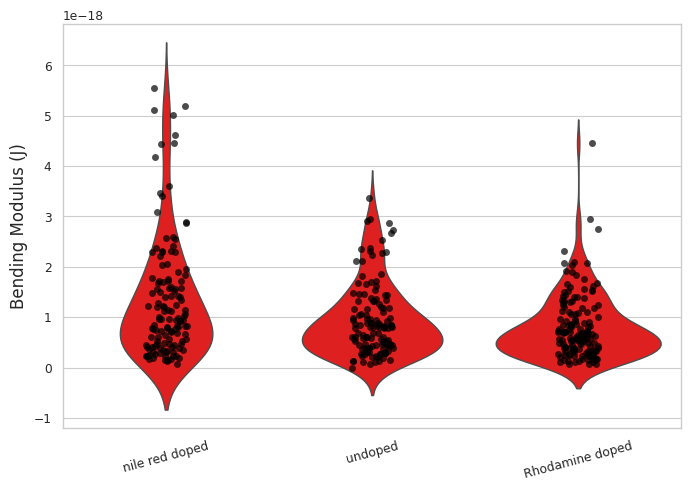

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

plt.figure(figsize=(7, 5))

sns.violinplot(
    data=data,
    x="system",
    y="Bending Modulus",
    inner=None,
    color="red",
    linewidth=1
)


sns.stripplot(
    data=data,
    x="system",
    y="Bending Modulus",
    color="black",
    size=5,
    jitter=True,
    alpha=0.7
)

plt.xlabel("")
plt.ylabel("Bending Modulus (J)", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

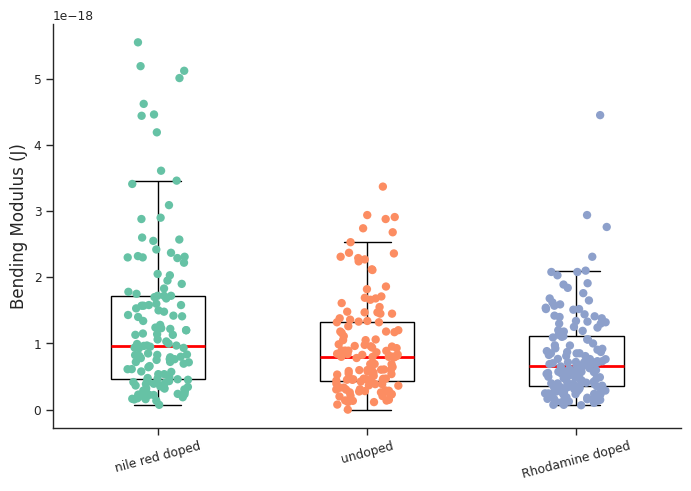

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", context="paper")

plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=data,
    x="system",
    y="Bending Modulus",
    width=0.45,
    showcaps=True,
    showfliers=False,
    boxprops=dict(facecolor="white", edgecolor="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="red", linewidth=2)
)

sns.stripplot(
    data=data,
    x="system",
    y="Bending Modulus",
    hue="system",
    palette="Set2",
    size=6,
    jitter=0.15,
    dodge=False,
    legend=False
)

ax.set_xlabel("")
ax.set_ylabel("Bending Modulus (J)", fontsize=12)

plt.xticks(rotation=15)
sns.despine()
plt.tight_layout()
plt.show()

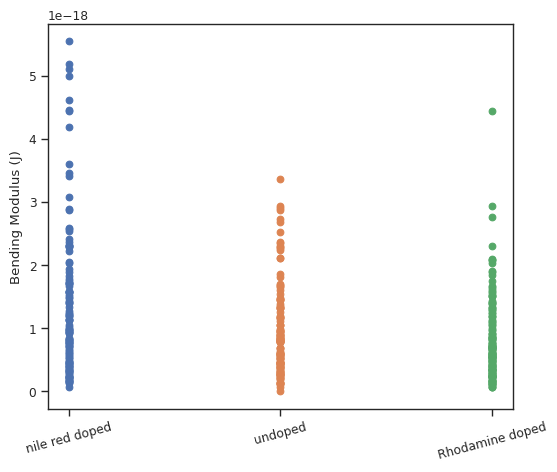

In [15]:
import matplotlib.pyplot as plt

systems = data["system"].unique()

plt.figure(figsize=(6,5))

for i, s in enumerate(systems):
    y = data[data["system"] == s]["Bending Modulus"]
    x = [i+1] * len(y)
    plt.scatter(x, y)

plt.xticks(range(1, len(systems)+1), systems, rotation=15)
plt.ylabel("Bending Modulus (J)")

plt.show()


System: nile red doped
Shapiro–Wilk statistic = 0.8275
P-value = 0.0000
Reject H0: Data does not appear normally distributed.


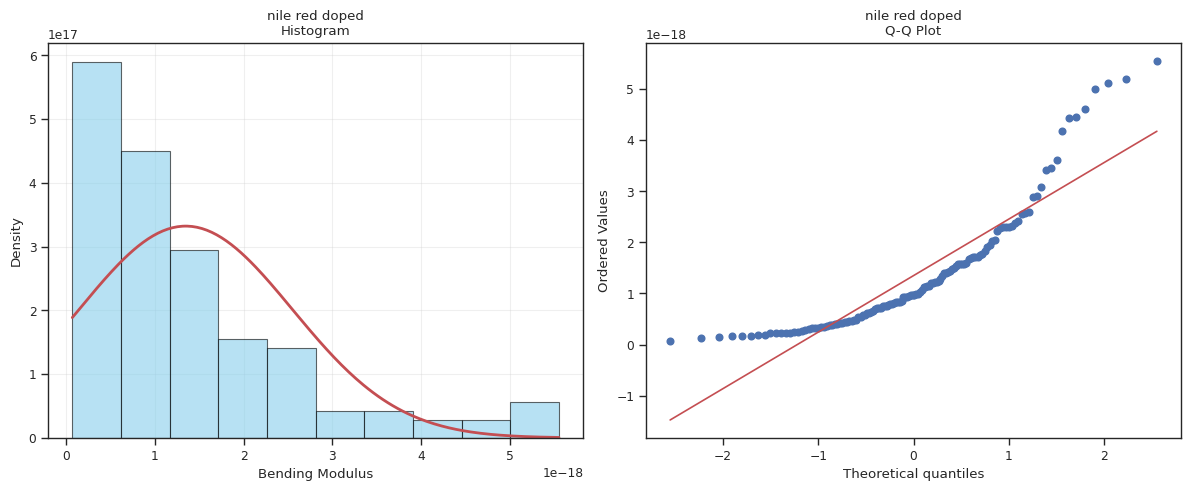


System: undoped
Shapiro–Wilk statistic = 0.8845
P-value = 0.0000
Reject H0: Data does not appear normally distributed.


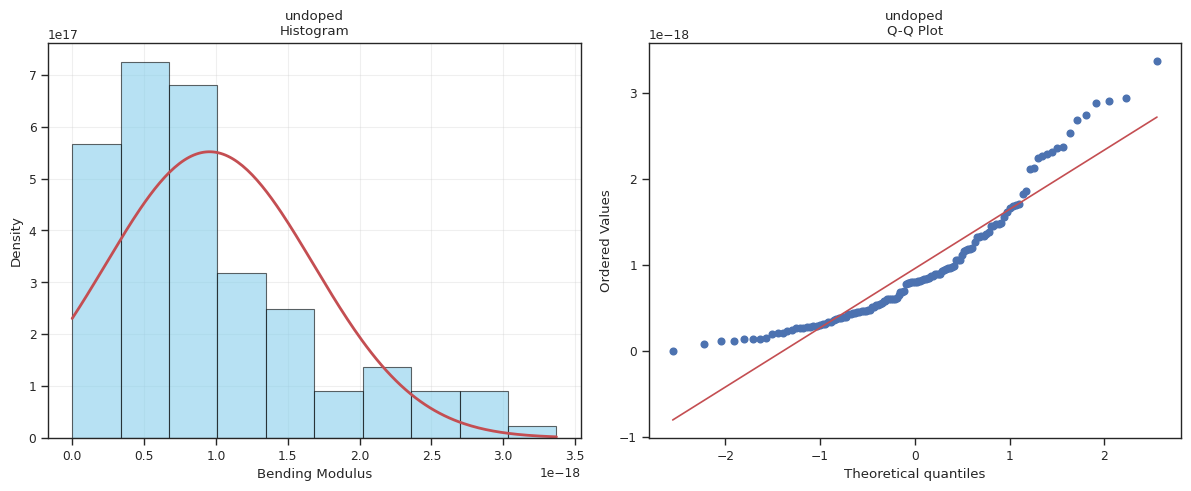


System: Rhodamine doped
Shapiro–Wilk statistic = 0.8444
P-value = 0.0000
Reject H0: Data does not appear normally distributed.


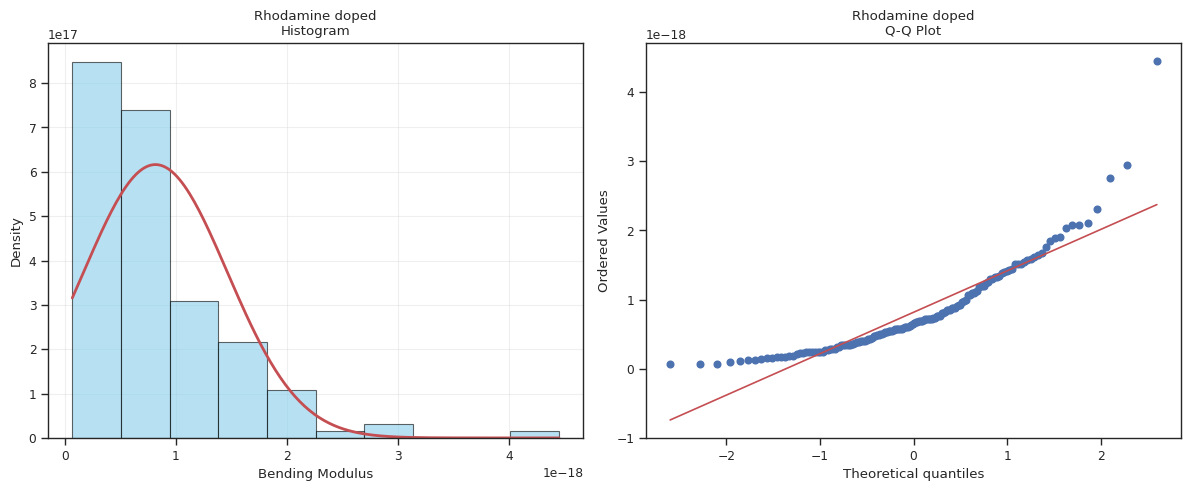

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro

# Loop through each system
for s in data["system"].unique():

    values = data.loc[data["system"] == s, "Bending Modulus"]

    # Shapiro-Wilk Test
    stat, p = shapiro(values)

    print(f"\nSystem: {s}")
    print(f"Shapiro–Wilk statistic = {stat:.4f}")
    print(f"P-value = {p:.4f}")

    if p > 0.05:
        print("Fail to reject H0: Data appears normally distributed.")
    else:
        print("Reject H0: Data does not appear normally distributed.")

    # ---------------------------------
    # Histogram + Normal Distribution
    # ---------------------------------
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)

    plt.hist(values, bins=10, density=True,
             alpha=0.6, color='skyblue',
             edgecolor='black')

    mu = np.mean(values)
    sigma = np.std(values, ddof=1)

    x = np.linspace(values.min(), values.max(), 200)
    pdf = stats.norm.pdf(x, mu, sigma)

    plt.plot(x, pdf, 'r', linewidth=2)
    plt.title(f"{s}\nHistogram")
    plt.xlabel("Bending Modulus")
    plt.ylabel("Density")
    plt.grid(alpha=0.3)

    # ---------------------------------
    # Q-Q Plot
    # ---------------------------------
    plt.subplot(1,2,2)

    stats.probplot(values, dist="norm", plot=plt)

    plt.title(f"{s}\nQ-Q Plot")

    plt.tight_layout()
    plt.show()

In [17]:
from scipy.stats import levene

groups = [
    g["Bending Modulus"].values
    for _, g in data.groupby("system")
]

stat, p = levene(*groups)

print("Levene p =", p)

Levene p = 4.956677695675858e-06


levene test -checking for homogeneity of variance for independent groups here levene test fails since we reject HO

In [23]:
from scipy.stats import kruskal

groups = [
    g["Bending Modulus"].values
    for _, g in data.groupby("system")
]

H, p = kruskal(*groups)

print("H =", H)
print("p =", p)

H = 15.276551236814079
p = 0.0004816582990713102


In [24]:
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(
    data,
    val_col="Bending Modulus",
    group_col="system",
    p_adjust="holm"
)

print(dunn)

                 Rhodamine doped  nile red doped   undoped
Rhodamine doped         1.000000        0.000291  0.115225
nile red doped          0.000291        1.000000  0.047806
undoped                 0.115225        0.047806  1.000000


In [25]:
import scikit_posthocs as sp

# Dunn post-hoc test with Holm correction
dunn_results = sp.posthoc_dunn(
    data,
    val_col="Bending Modulus",
    group_col="system",
    p_adjust="holm"
)

print(dunn_results)

                 Rhodamine doped  nile red doped   undoped
Rhodamine doped         1.000000        0.000291  0.115225
nile red doped          0.000291        1.000000  0.047806
undoped                 0.115225        0.047806  1.000000


In [26]:
pairs = [
    ("Rhodamine doped", "undoped"),
    ("nile red doped", "undoped"),
    ("Rhodamine doped", "nile red doped")
]


for a, b in pairs:
    p = dunn_results.loc[a, b]
    print(f"{a} vs {b}: p = {p:.5e}")

Rhodamine doped vs undoped: p = 1.15225e-01
nile red doped vs undoped: p = 4.78056e-02
Rhodamine doped vs nile red doped: p = 2.90797e-04


In [27]:
import numpy as np
from scipy.stats import mannwhitneyu


def rank_biserial(group1, group2):

    U, p = mannwhitneyu(
        group1,
        group2,
        alternative="two-sided"
    )

    n1 = len(group1)
    n2 = len(group2)

    rbc = 1 - (2*U)/(n1*n2)

    return rbc, p


groups = {}

for name, group in data.groupby("system"):
    groups[name] = group["Bending Modulus"].values


comparisons = [
    ("Rhodamine doped", "undoped"),
    ("nile red doped", "undoped"),
    ("Rhodamine doped", "nile red doped")
]


for a, b in comparisons:

    effect, p = rank_biserial(
        groups[a],
        groups[b]
    )

    print(
        f"{a} vs {b}: effect size = {effect:.3f}, p={p:.5e}"
    )

Rhodamine doped vs undoped: effect size = 0.112, p=1.05264e-01
nile red doped vs undoped: effect size = -0.165, p=2.10305e-02
Rhodamine doped vs nile red doped: effect size = 0.268, p=1.18813e-04


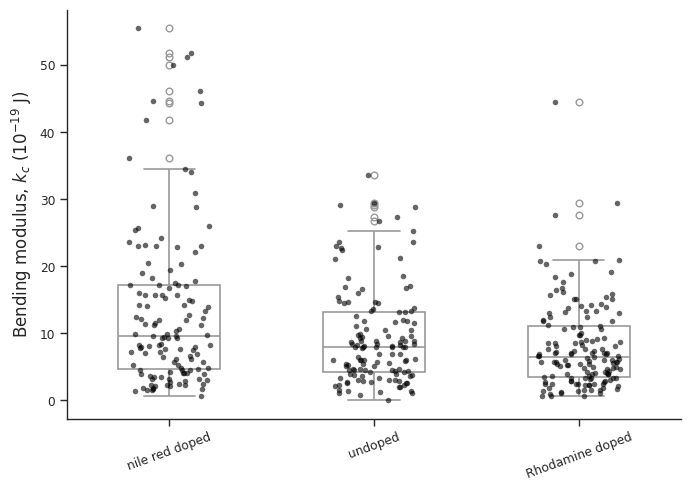

In [29]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=data,
    x="system",
    y="kc_scaled",
    width=0.5,
    color="white",
    linewidth=1.2
)

sns.stripplot(
    data=data,
    x="system",
    y="kc_scaled",
    color="black",
    size=4,
    jitter=0.2,
    alpha=0.6
)

plt.xlabel("")
plt.ylabel(r"Bending modulus, $k_c$ ($10^{-19}$ J)", fontsize=12)

plt.xticks(rotation=20)

sns.despine()
plt.tight_layout()

plt.show()

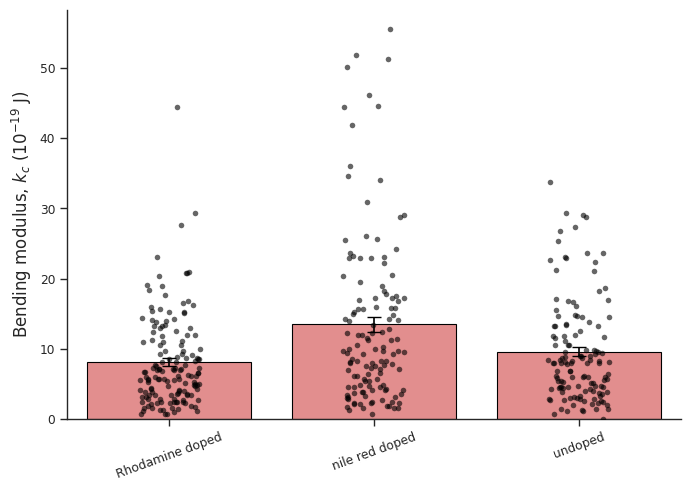

In [30]:
data["kc_scaled"] = data["Bending Modulus"] / 1e-19


summary = (
    data.groupby("system")["kc_scaled"]
    .agg(["mean", "sem"])
    .reset_index()
)


plt.figure(figsize=(7,5))

sns.barplot(
    data=summary,
    x="system",
    y="mean",
    color="lightcoral",
    edgecolor="black",
    errorbar=None
)


plt.errorbar(
    x=np.arange(len(summary)),
    y=summary["mean"],
    yerr=summary["sem"],
    fmt="none",
    c="black",
    capsize=5
)


sns.stripplot(
    data=data,
    x="system",
    y="kc_scaled",
    color="black",
    size=4,
    jitter=0.15,
    alpha=0.6
)


plt.xlabel("")
plt.ylabel(r"Bending modulus, $k_c$ ($10^{-19}$ J)", fontsize=12)

plt.xticks(rotation=20)

sns.despine()
plt.tight_layout()

plt.show()